# ECG Arrhythmia Classification using GA-Optimized 1D CNN

This notebook implements an end-to-end deep learning framework for ECG heartbeat classification using a Genetic Algorithm (GA) to optimize CNN hyperparameters.

**Key features:**
- Minimal preprocessing
- Class-aware data augmentation
- GA-driven hyperparameter optimization

## 1. Imports and Dependencies

In [ ]:
import tensorflow as tf
import IPython
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set()

seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

## 2. Dataset

This study uses the MIT-BIH Arrhythmia dataset, prepared following the approach of Kachuee et al.

- Source: Kaggle heartbeat dataset
- Each sample: 187-point ECG heartbeat
- Classes: N, S, V, F, Q

In [ ]:

train_data = pd.read_csv('mitbih/mitbih_train.csv', header=None)
train_data = pd.DataFrame(train_data)
test_data = pd.read_csv('mitbih/mitbih_test.csv', header=None)
test_data = pd.DataFrame(test_data)

In [ ]:
# specify the classes of the training data

class0 = train_data[train_data[187]==0.0] #N
class1 = train_data[train_data[187]==1.0] #S
class2 = train_data[train_data[187]==2.0] #V
class3 = train_data[train_data[187]==3.0] #F
class4 = train_data[train_data[187]==4.0] #Q

train_data = pd.concat([class0, class1, class2, class3, class4])
V = train_data[187].value_counts()
print(V)

187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64


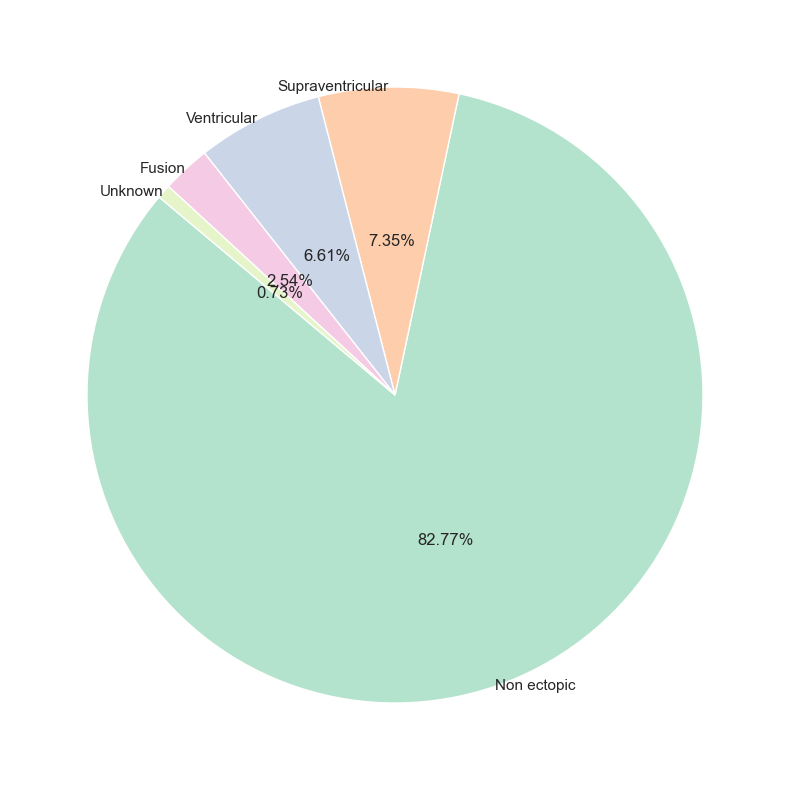

In [ ]:
# visualize data distribution in the training data

label = ["Non ectopic", "Supraventricular", "Ventricular", "Fusion", "Unknown"]
clr = ['yellowgreen', 'khaki', "paleturquoise", "slategray", "thistle"]

plt.figure(figsize=(10,10))
circ = plt.Circle((0,0), 0, color='white')
plt.pie(V, labels=label, colors=plt.cm.Pastel2.colors, autopct="%0.2f%%", labeldistance=1, pctdistance=0.5, startangle=140)
p = plt.gcf()
p.gca().add_artist(circ)
plt.show()

In [ ]:
# specify the classes of the testing data

class0_t = test_data[test_data[187]==0.0] #N
class1_t = test_data[test_data[187]==1.0] #S
class2_t = test_data[test_data[187]==2.0] #V
class3_t = test_data[test_data[187]==3.0] #F
class4_t = test_data[test_data[187]==4.0] #Q

test_data = pd.concat([class0_t, class1_t, class2_t, class3_t, class4_t])
Vt = test_data[187].value_counts()
print(Vt)

187
0.0    18118
4.0     1608
2.0     1448
1.0      556
3.0      162
Name: count, dtype: int64


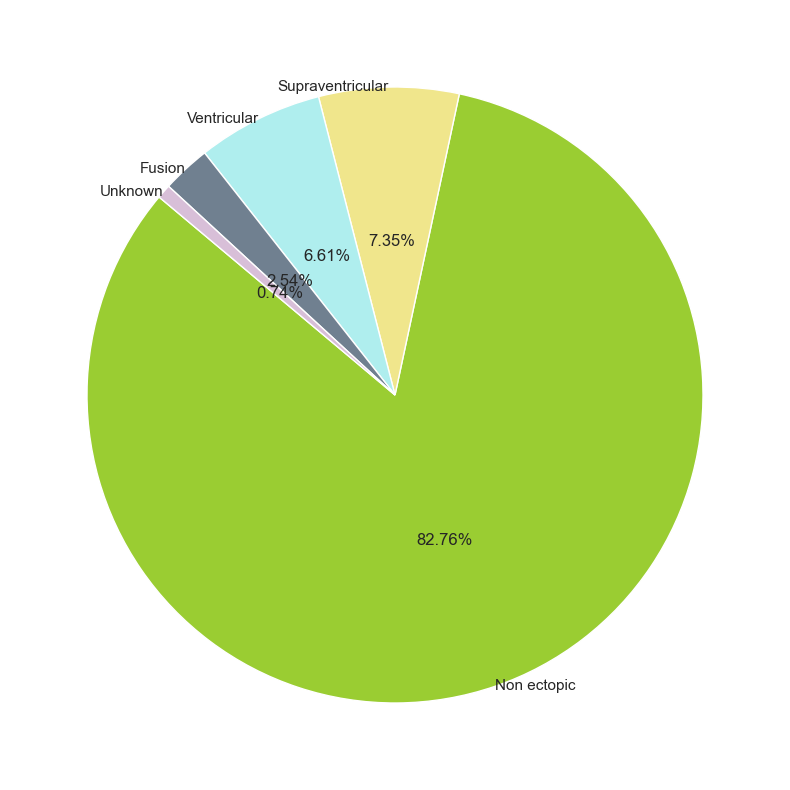

In [ ]:
# visualize data distribution in the testing data

plt.figure(figsize=(10,10))
crc = plt.Circle((0,0), 0, color='white')
plt.pie(Vt, labels=label, colors=clr, autopct="%0.2f%%", labeldistance=1, pctdistance=0.5, startangle=140)
pt = plt.gcf()
pt.gca().add_artist(crc)
plt.show()

In [ ]:
# split the training and testing data into features and labels

from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

x_train = train_data.drop([187], axis=1)
y_train = train_data.values[:, -1]

X_test = test_data.drop([187], axis=1)
Y_test = test_data.values[:, -1]


In [ ]:
# print the shape of the training and testing data

print(f"shape of X train is: {x_train.shape}")
print(f"shape of Y train is: {y_train.shape}")
print(f"shape of X test is: {X_test.shape}")
print(f"shape of Y test is: {Y_test.shape}")

shape of X train is: (87554, 187)
shape of Y train is: (87554,)
shape of X test is: (21892, 187)
shape of Y test is: (21892,)


In [ ]:
# print the number of samples in each class in the training and testing data

print(Counter(y_train))
print(Counter(Y_test))

Counter({0.0: 72471, 4.0: 6431, 2.0: 5788, 1.0: 2223, 3.0: 641})
Counter({0.0: 18118, 4.0: 1608, 2.0: 1448, 1.0: 556, 3.0: 162})


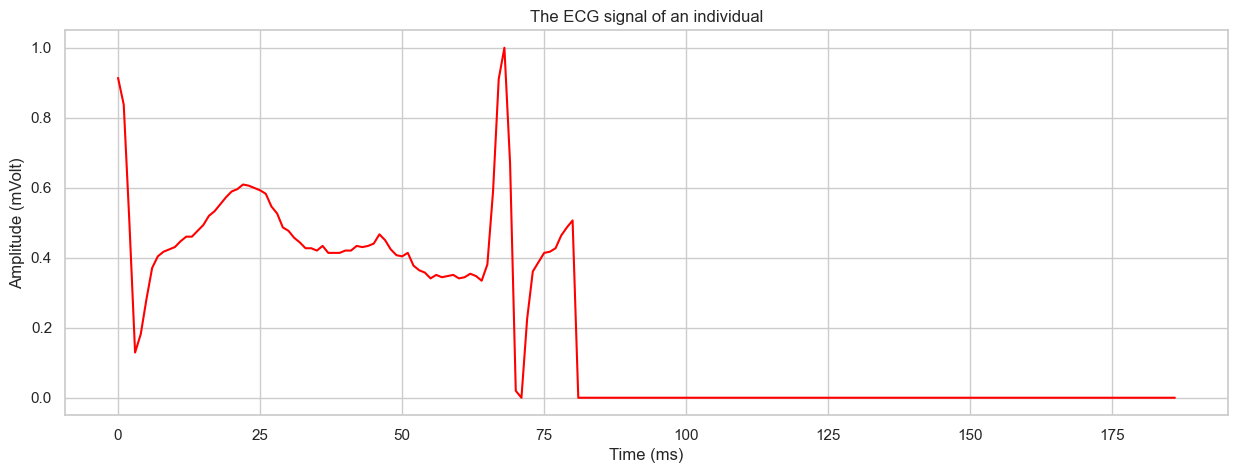

In [ ]:
# show real representation of the ECG signal of an individual

sns.set_style('whitegrid')
plt.figure(figsize=(15,5))
plt.title('The ECG signal of an individual')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (mVolt)')
plt.plot(x_train.iloc[56230], color='red')

## 4. Data Augmentation

To address class imbalance:
- Gaussian noise injection
- Controlled amplitude modulation
- Applied only to minority classes

This preserves ECG morphology while increasing diversity.

In [ ]:


from scipy.signal import resample, find_peaks
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
from imblearn.over_sampling import SMOTE
import random
import numpy as np
import pandas as pd

class ECGAugmenter:
    def __init__(self, signal_length=187, random_state=42):
        self.signal_length = signal_length
        self.random_state = random_state
        self.class_statistics = {}
        self.diversity_threshold = 0.8
        np.random.seed(random_state)
        random.seed(random_state)
        
    def compute_class_statistics(self, data, labels):
        """Compute class-specific statistics for targeted augmentation"""
        stats = {}
        unique_labels = np.unique(labels)
        
        for label in unique_labels:
            class_data = data[labels == label]
            stats[label] = {
                'mean': np.mean(class_data, axis=0),
                'std': np.std(class_data, axis=0),
                'peak_locations': self._find_peak_locations(np.mean(class_data, axis=0)),
                'mean_amplitude': np.mean(np.abs(class_data)),
                'std_amplitude': np.std(np.abs(class_data))
            }
        return stats
    
    def _find_peak_locations(self, signal):
        """Find important peaks in the signal"""
        peaks, _ = find_peaks(np.abs(signal), height=np.std(signal))
        return peaks
    
    def class_aware_noise(self, signal, label, noise_factor=0.15):
        """Add minimal noise based on class-specific characteristics"""
        class_std = self.class_statistics[label]['std_amplitude']
        actual_noise = noise_factor * class_std * np.random.uniform(0.3, 0.7)
        noise = np.random.normal(0, actual_noise, len(signal))
        
        # Reduce noise around important peaks
        peak_locations = self.class_statistics[label]['peak_locations']
        for peak in peak_locations:
            window = slice(max(0, peak-5), min(len(signal), peak+6))
            noise[window] *= 0.3
            
        return signal + noise
    
    def class_aware_amplitude_modulation(self, signal, label):
        """Amplitude modulation that preserves class-specific characteristics"""
        peaks = np.abs(signal)
        mean_amp = self.class_statistics[label]['mean_amplitude']
        std_amp = self.class_statistics[label]['std_amplitude']
        
        threshold = mean_amp + std_amp
        
        t = np.linspace(0, 2*np.pi, len(signal))
        # Reduced modulation depth for more subtle changes
        mod_depth = np.random.uniform(0.10, 0.14) * (std_amp / mean_amp)
        modulation = 1 + mod_depth * np.sin(t + np.random.uniform(0, 2*np.pi))
        
        peak_mask = peaks > threshold
        modified_modulation = np.ones_like(signal)
        modified_modulation[~peak_mask] = modulation[~peak_mask]
        
        return signal * modified_modulation
    
    def diversity_check(self, new_signal, existing_signals, threshold=0.85):
        """Check if new signal is sufficiently different from existing ones"""
        if len(existing_signals) == 0:
            return True
            
        correlations = [np.corrcoef(new_signal, existing)[0,1] 
                       for existing in existing_signals]
        return np.mean(correlations) < threshold
    
    def augment_with_diversity(self, data, labels, augmentation_factors=None, max_attempts=3):
        """Generate diverse augmented samples with class-specific characteristics
        
        Args:
            data: Input data array or DataFrame
            labels: Input labels array or Series
            augmentation_factors: Dict mapping class labels to multiplication factors
                                e.g., {1.0: 2, 2.0: 1.5} to double class 1 and increase class 2 by 50%
            max_attempts: Maximum number of attempts to generate diverse samples
        """
        if isinstance(data, pd.DataFrame):
            data_array = data.to_numpy()
        else:
            data_array = np.array(data)
            
        if isinstance(labels, pd.Series):
            labels_array = labels.to_numpy()
        else:
            labels_array = np.array(labels)
        
        # Compute class statistics
        self.class_statistics = self.compute_class_statistics(data_array, labels_array)
        
        unique_labels, counts = np.unique(labels_array, return_counts=True)
        
        # If no augmentation factors provided, create default ones
        if augmentation_factors is None:
            augmentation_factors = {}
            for label, count in zip(unique_labels, counts):
                if count < counts.max():
                    # Default to doubling the size of minority classes
                    augmentation_factors[label] = 2.0
        
        augmented_data = list(data_array)
        augmented_labels = list(labels_array)
        class_augmented_samples = defaultdict(list)
        
        for label in unique_labels:
            if label not in augmentation_factors or augmentation_factors[label] <= 1.0:
                continue
                
            class_mask = labels_array == label
            class_data = data_array[class_mask]
            class_count = len(class_data)
            
            # Calculate samples to generate - FIXED: calculate correctly based on factor
            # Target count is original count * factor
            target_count = int(class_count * augmentation_factors[label])
            # We need to generate (target - original) new samples
            samples_to_generate = target_count - class_count
            
            if samples_to_generate > 0:
                print(f"Class {label}: Generating {samples_to_generate} samples to reach factor {augmentation_factors[label]}")
                for _ in range(samples_to_generate):
                    idx = np.random.randint(0, class_count)
                    signal = class_data[idx].copy()
                    
                    # Apply augmentations with conservative parameters
                    if random.random() < 0.8:
                        signal = self.class_aware_noise(signal, label)
                    if random.random() < 0.6:
                        signal = self.class_aware_amplitude_modulation(signal, label)
                        
                    # Only add if sufficiently diverse
                    if self.diversity_check(signal, class_augmented_samples[label]):
                        class_augmented_samples[label].append(signal)
                        augmented_data.append(signal)
                        augmented_labels.append(label)

        return np.array(augmented_data), np.array(augmented_labels)

Using SMOTE as a hybrid approach with the class aware data augmentation approach above to synthesis samples of the minority classes.

In [ ]:
# Using SMOTE as a hybrid approach with
# 

class HybridECGAugmenter:
    def __init__(self, signal_length=187, random_state=42):
        self.signal_length = signal_length
        self.random_state = random_state
        self.class_statistics = {}
        self.diversity_threshold = 0.8
        self.ecg_augmenter = ECGAugmenter(signal_length, random_state)
        np.random.seed(random_state)
        random.seed(random_state)
    
    def hybrid_augment(self, data, labels, initial_augmentation_factors=None, target_ratio=0.2):
        """
        Two-stage augmentation:
        1. Signal-aware augmentation using ECGAugmenter
        2. SMOTE to reach target ratio of majority class
        
        Args:
            data: Input data array or DataFrame
            labels: Input labels array or Series
            initial_augmentation_factors: Dict mapping class labels to multiplication factors
            target_ratio: Target ratio relative to majority class for final SMOTE step
        """
        # Default augmentation factors if none provided
        if initial_augmentation_factors is None:
            initial_augmentation_factors = {
                3.0: 3.0,  # Triple the smallest class
                1.0: 2.5,  # Increase class 1 by 150%
                2.0: 1.5,  # Increase class 2 by 50%
                4.0: 1.5,  # Increase class 4 by 50%
                0.0: 1.0   # No augmentation for majority class
            }
        
        # Stage 1: Signal-aware augmentation
        print("Stage 1: Performing signal-aware augmentation...")
        X_aug_1, y_aug_1 = self.ecg_augmenter.augment_with_diversity(
            data, 
            labels, 
            augmentation_factors=initial_augmentation_factors
        )
        
        # Calculate class distribution after first stage
        unique_labels, counts = np.unique(y_aug_1, return_counts=True)
        majority_count = counts.max()
        
        # Calculate target counts for each class
        target_counts = {}
        for label in unique_labels:
            target_counts[label] = int(majority_count * target_ratio)
        
        # Stage 2: Apply SMOTE
        print("Stage 2: Applying SMOTE...")
        sampling_strategy = {
            label: max(count, counts[unique_labels == label][0]) 
            for label, count in target_counts.items()
            if count > counts[unique_labels == label][0]  # Only oversample if target is higher
        }
        
        if sampling_strategy:  # Only apply SMOTE if there are classes to oversample
            # Automatically adjust k_neighbors based on smallest class
            smallest_class_size = min([counts[unique_labels == label][0] for label in sampling_strategy.keys()])
            k_neighbors = min(5, smallest_class_size-1) if smallest_class_size > 1 else 1
            
            smote = SMOTE(
                sampling_strategy=sampling_strategy,
                random_state=self.random_state,
                k_neighbors=k_neighbors
            )
            X_aug_final, y_aug_final = smote.fit_resample(X_aug_1, y_aug_1)
        else:
            X_aug_final, y_aug_final = X_aug_1, y_aug_1
        
        # Print augmentation statistics
        self._print_augmentation_stats(labels, y_aug_1, y_aug_final)
        
        return X_aug_final, y_aug_final
    
    def _print_augmentation_stats(self, original_labels, stage1_labels, final_labels):
        """Print statistics about the augmentation process"""
        def get_distribution(labels):
            unique, counts = np.unique(labels, return_counts=True)
            return dict(zip(unique, counts))
        
        orig_dist = get_distribution(original_labels)
        stage1_dist = get_distribution(stage1_labels)
        final_dist = get_distribution(final_labels)
        
        print("\nAugmentation Statistics:")
        print("\nClass | Original | After Signal-Aware | After SMOTE")
        print("-" * 50)
        for label in sorted(orig_dist.keys()):
            orig = orig_dist.get(label, 0)
            stage1 = stage1_dist.get(label, 0)
            final = final_dist.get(label, 0)
            
            # Calculate and display multiplicative factors
            stage1_factor = stage1 / orig if orig > 0 else 0
            final_factor = final / orig if orig > 0 else 0
            
            print(f"{label:5} | {orig:8} | {stage1:8} ({stage1_factor:.2f}x) | {final:8} ({final_factor:.2f}x)")

def augment_ecg_dataset(X_train, y_train, initial_augmentation_factors=None, target_ratio=0.2):
    """
    Convenience function to augment ECG dataset using the hybrid approach
    
    Args:
        X_train: Training data array or DataFrame
        y_train: Training labels array or Series
        initial_augmentation_factors: Dict mapping class labels to multiplication factors
        target_ratio: Target ratio relative to majority class for final SMOTE step
    """
    # Convert to numpy arrays if needed
    if isinstance(X_train, pd.DataFrame):
        X_train = X_train.to_numpy()
    if isinstance(y_train, pd.Series):
        y_train = y_train.to_numpy()
    
    # Create and apply hybrid augmenter
    augmenter = HybridECGAugmenter(signal_length=X_train.shape[1])
    return augmenter.hybrid_augment(
        X_train, 
        y_train,
        initial_augmentation_factors=initial_augmentation_factors,
        target_ratio=target_ratio
    )

In [ ]:
# Define initial augmentation factors for signal-aware stage

initial_augmentation_factors = {
    3.0: 4.0,  # Triple the smallest class
    1.0: 3.5,  # Increase class 1 by 150%
    2.0: 2.0,  # Increase class 2 by 50%
    4.0: 2.0,  # Increase class 4 by 50%
    0.0: 1.0   # No augmentation for majority class
}

# Apply hybrid augmentation
X_augmented, y_augmented = augment_ecg_dataset(
    x_train, 
    y_train,
    initial_augmentation_factors=initial_augmentation_factors,
    target_ratio=0.2  # Final target: 30% of majority class
)

Stage 1: Performing signal-aware augmentation...
Class 1.0: Generating 5557 samples to reach factor 3.5
Class 2.0: Generating 5788 samples to reach factor 2.0
Class 3.0: Generating 1923 samples to reach factor 4.0
Class 4.0: Generating 6431 samples to reach factor 2.0
Stage 2: Applying SMOTE...

Augmentation Statistics:

Class | Original | After Signal-Aware | After SMOTE
--------------------------------------------------
  0.0 |    72471 |    72471 (1.00x) |    72471 (1.00x)
  1.0 |     2223 |     7780 (3.50x) |    14494 (6.52x)
  2.0 |     5788 |    11576 (2.00x) |    14494 (2.50x)
  3.0 |      641 |     2563 (4.00x) |    14494 (22.61x)
  4.0 |     6431 |    12862 (2.00x) |    14494 (2.25x)


In [ ]:
import numpy as np
from scipy import stats
import pandas as pd

def perform_ks_analysis_numpy(X_original, y_original, X_augmented, y_augmented):
    """
    Perform Kolmogorov-Smirnov test on ECG signals with improved robustness and data type handling.
    """
    def normalize_signal(x):
        """Normalize signals while preserving relative amplitudes"""
        # Convert to numpy array if not already
        x = np.array(x)
        if x.ndim == 1:
            x = x.reshape(1, -1)
        return x / (np.max(np.abs(x), axis=1, keepdims=True) + 1e-10)
    
    def remove_baseline(x):
        """Remove baseline wander using median filtering"""
        # Convert to numpy array if not already
        x = np.array(x)
        if x.ndim == 1:
            x = x.reshape(1, -1)
            
        x_norm = x.copy()
        # Use vectorized operations instead of loop
        x_norm = x_norm - np.median(x_norm, axis=1)[:, np.newaxis]
        return x_norm
    
    def robust_max_amplitude(x):
        """Calculate max amplitude more robustly"""
        return np.percentile(np.abs(x), 99.5, axis=1)
    
    def robust_peak_to_peak(x):
        """Calculate peak-to-peak more robustly"""
        return np.percentile(x, 97.5, axis=1) - np.percentile(x, 2.5, axis=1)
    
    # Convert inputs to numpy arrays if they aren't already
    X_original = np.array(X_original)
    X_augmented = np.array(X_augmented)
    y_original = np.array(y_original)
    y_augmented = np.array(y_augmented)
    
    # Ensure 2D arrays
    if X_original.ndim == 1:
        X_original = X_original.reshape(1, -1)
    if X_augmented.ndim == 1:
        X_augmented = X_augmented.reshape(1, -1)
    
    # Statistical properties to compare
    properties = {
        'mean': lambda x: np.mean(x, axis=1),
        'std': lambda x: np.std(x, axis=1),
        'skew': lambda x: stats.skew(x, axis=1),
        'kurtosis': lambda x: stats.kurtosis(x, axis=1),
        'max_amplitude': robust_max_amplitude,
        'peak_to_peak': robust_peak_to_peak,
        'rms': lambda x: np.sqrt(np.mean(np.square(x), axis=1))
    }
    
    try:
        # Preprocess signals
        X_orig_norm = normalize_signal(remove_baseline(X_original))
        X_aug_norm = normalize_signal(remove_baseline(X_augmented))
    except Exception as e:
        print(f"Error during signal preprocessing: {str(e)}")
        raise
    
    # Get unique classes
    classes = np.unique(np.concatenate([y_original, y_augmented]))
    results = []
    
    for class_label in classes:
        # Extract signals for current class
        orig_mask = y_original == class_label
        aug_mask = y_augmented == class_label
        
        orig_signals = X_orig_norm[orig_mask]
        aug_signals = X_aug_norm[aug_mask]
        
        if len(orig_signals) == 0 or len(aug_signals) == 0:
            print(f"Warning: No data found for class {class_label}")
            continue
        
        for prop_name, prop_func in properties.items():
            try:
                # Calculate properties
                orig_prop = prop_func(orig_signals)
                aug_prop = prop_func(aug_signals)
                
                # Remove any NaN or infinite values
                orig_prop = orig_prop[np.isfinite(orig_prop)]
                aug_prop = aug_prop[np.isfinite(aug_prop)]
                
                if len(orig_prop) < 5 or len(aug_prop) < 5:
                    print(f"Warning: Insufficient data for {prop_name} in class {class_label}")
                    continue
                
                # Perform KS test
                ks_stat, p_value = stats.ks_2samp(orig_prop, aug_prop)
                
                results.append({
                    'Class': class_label,
                    'Property': prop_name,
                    'KS_Statistic': ks_stat,
                    'P_Value': p_value,
                    'Similar_Distribution': p_value > 0.05,
                    'Original_Size': len(orig_signals),
                    'Augmented_Size': len(aug_signals),
                    'Original_Mean': np.mean(orig_prop),
                    'Augmented_Mean': np.mean(aug_prop),
                    'Percent_Diff': 100 * abs(np.mean(orig_prop) - np.mean(aug_prop)) / np.mean(orig_prop)
                })
                
            except Exception as e:
                print(f"Error processing {prop_name} for class {class_label}: {str(e)}")
                continue
    
    return pd.DataFrame(results)

In [ ]:


def plot_ks_test_heatmap(results_df):
    """
    Create a heatmap visualization of KS test p-values by class and property.
    
    Parameters:
    results_df (pd.DataFrame): DataFrame containing KS test results with columns:
                             'Class', 'Property', 'P_Value'
    """
    # Pivot the data to create a matrix of p-values
    pivot_table = results_df.pivot(index='Property', columns='Class', values='P_Value')
    
    # Create figure with appropriate size
    plt.figure(figsize=(12, 8))
    
    # Create heatmap
    sns.heatmap(pivot_table, 
                annot=True,  # Show p-values in cells
                fmt='.3f',   # Format p-values to 3 decimal places
                cmap='YlGn', # Yellow-Green colormap (yellow for low values, green for high)
                vmin=0,      # Minimum value for colormap
                vmax=1,      # Maximum value for colormap
                cbar_kws={'label': 'P-Value'})
    
    # Customize the plot
    plt.title('KS Test P-Values by Class and Property')
    plt.xlabel('Class')
    plt.ylabel('Property')
    
    # Rotate x-axis labels if needed
    plt.xticks(rotation=0)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    return plt.gcf()




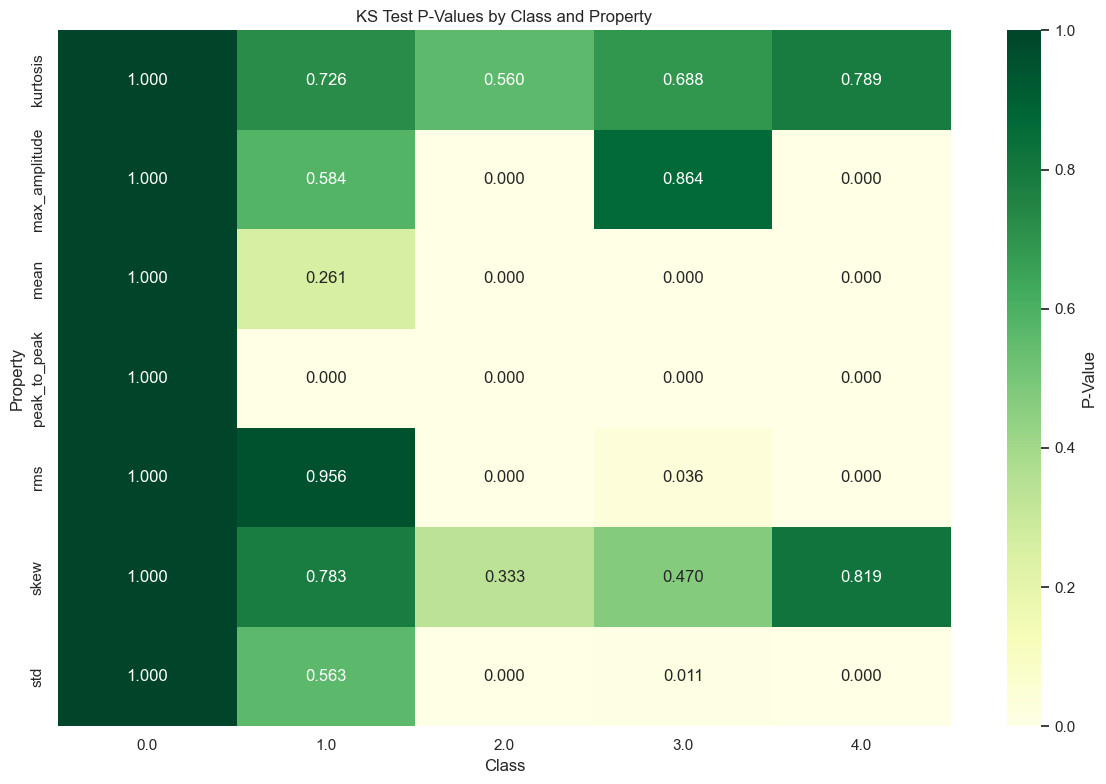

In [ ]:
# Example usage:
results = perform_ks_analysis_numpy(x_train, y_train, X_augmented, y_augmented)

plot_ks_test_heatmap(results)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def print_augmentation_statistics(original_labels, augmented_labels):
    """
    Print detailed statistics about the original and augmented dataset.
    
    Args:
        original_labels: Array of labels from original dataset
        augmented_labels: Array of labels after augmentation
    """
    unique_labels = np.unique(original_labels)
    
    print("\n=== Dataset Augmentation Statistics ===")
    print(f"{'Class':<10} {'Original':<12} {'Augmented':<12} {'Total':<12} {'Increase %':<12}")
    print("-" * 58)
    
    for label in unique_labels:
        if label == 0:  # Skip class 0 as it's not augmented
            orig_count = np.sum(original_labels == label)
            print(f"{label:<10} {orig_count:<12} {0:<12} {orig_count:<12} {0:<12}")
            continue
            
        orig_count = np.sum(original_labels == label)
        aug_count = np.sum(augmented_labels == label) - orig_count
        total_count = orig_count + aug_count
        increase_percent = (aug_count / orig_count * 100) if orig_count > 0 else 0
        
        print(f"{label:<10} {orig_count:<12} {aug_count:<12} {total_count:<12} {increase_percent:.1f}%")
    
    print("-" * 58)
    print(f"Total: {len(original_labels)} original + {len(augmented_labels) - len(original_labels)} augmented = {len(augmented_labels)} total")

def visualize_ecg_augmentations(augmenter, data, labels, num_examples=3):
    """
    Visualize original ECG beats and their augmented versions using the ECGAugmenter class,
    skipping class 0 and without difference plots.
    
    Args:
        augmenter: Instance of ECGAugmenter class
        data: Array of ECG signals
        labels: Array of corresponding labels
        num_examples: Number of examples to visualize per class
    """
    # Ensure data is in float format
    data = np.array(data, dtype=np.float32)
    labels = np.array(labels)
    
    # Compute class statistics if not already computed
    if not augmenter.class_statistics:
        augmenter.class_statistics = augmenter.compute_class_statistics(data, labels)
    
    unique_labels = np.unique(labels)
    
    for label in unique_labels:
        # Skip class 0
        if label == 0:
            continue
            
        # Get indices for this class
        class_indices = np.where(labels == label)[0]
        
        if len(class_indices) == 0:
            continue
            
        # Sample random beats
        sample_indices = np.random.choice(class_indices, 
                                        min(num_examples, len(class_indices)), 
                                        replace=False)
        
        for i, idx in enumerate(sample_indices):
            # Create a new figure for each beat
            plt.figure(figsize=(15, 5))
            
            original_beat = data[idx].copy()
            
            # Generate augmentations using ECGAugmenter methods
            noise_aug = augmenter.class_aware_noise(original_beat, label)
            amp_aug = augmenter.class_aware_amplitude_modulation(original_beat, label)
            
            # Plot original vs noise augmentation
            plt.subplot(1, 2, 1)
            plt.plot(original_beat, 'b-', label='Original', linewidth=2)
            plt.plot(noise_aug, 'r-', label='Noise Aug', alpha=0.7)
            plt.title(f'Class {label} - Original vs Noise Augmented')
            plt.grid(True)
            plt.legend()
            
            # Plot original vs amplitude augmentation
            plt.subplot(1, 2, 2)
            plt.plot(original_beat, 'b-', label='Original', linewidth=2)
            plt.plot(amp_aug, 'r-', label='Amplitude Aug', alpha=0.7)
            plt.title(f'Class {label} - Original vs Amplitude Augmented')
            plt.grid(True)
            plt.legend()
            
            plt.tight_layout()
            plt.show()
            
            # Print statistics
            print(f"\nStatistics for beat {i+1} of class {label}:")
            print(f"Original beat range: [{np.min(original_beat):.3f}, {np.max(original_beat):.3f}]")
            print(f"Noise augmented range: [{np.min(noise_aug):.3f}, {np.max(noise_aug):.3f}]")
            print(f"Amplitude augmented range: [{np.min(amp_aug):.3f}, {np.max(amp_aug):.3f}]")


'\n# Initialize the augmenter\naugmenter = ECGAugmenter()\n\n# Your data loading code here\n# data = ...\n# labels = ...\n\n# Perform augmentation\naugmented_data, augmented_labels = augmenter.augment_with_diversity(data, labels)\n\n# Print statistics about the augmentation\nprint_augmentation_statistics(labels, augmented_labels)\n\n# Visualize the augmentations\nvisualize_ecg_augmentations(augmenter, augmented_data, augmented_labels, num_examples=2)\n'

In [ ]:
# Print statistics about the augmentation
print_augmentation_statistics(y_train, y_augmented)

# Visualize the augmentations
visualize_ecg_augmentations(augmenter, X_augmented, y_augmented, num_examples=10)

In [ ]:
# print the number of samples in training data after augmentation and testing data without augmentation

print(Counter(y_augmented))
print(Counter(Y_test))
#print(Counter(Y_valid))

Counter({0.0: 72471, 1.0: 14494, 2.0: 14494, 4.0: 14493, 3.0: 14491})
Counter({0.0: 18118, 4.0: 1608, 2.0: 1448, 1.0: 556, 3.0: 162})


In [ ]:
# print the shape of the training and testing data

print(f"shape of X train is: {X_augmented.shape}")
print(f"shape of Y train is: {y_augmented.shape}")
print(f"shape of X test is: {X_test.shape}")
print(f"shape of Y test is: {Y_test.shape}")

shape of X train is: (130443, 187)
shape of Y train is: (130443,)
shape of X test is: (21892, 187)
shape of Y test is: (21892,)


In [ ]:
def visualize_class_distributions(original_data, augmented_data, original_labels, augmented_labels):
    plt.figure(figsize=(15, 5))
    
    # Plot sample distributions
    plt.subplot(121)
    for class_label in np.unique(original_labels):
        orig_samples = original_data[original_labels == class_label]
        aug_samples = augmented_data[augmented_labels == class_label]
        
        plt.hist(orig_samples.mean(axis=1), alpha=0.5, label=f'Original Class {class_label}', bins=20)
        plt.hist(aug_samples.mean(axis=1), alpha=0.5, label=f'Augmented Class {class_label}', bins=20)
    
    plt.title('Distribution of Signal Means by Class')
    plt.legend()
    
    # Plot sample variances
    plt.subplot(122)
    for class_label in np.unique(original_labels):
        orig_samples = original_data[original_labels == class_label]
        aug_samples = augmented_data[augmented_labels == class_label]
        
        plt.hist(orig_samples.std(axis=1), alpha=0.5, label=f'Original Class {class_label}', bins=20)
        plt.hist(aug_samples.std(axis=1), alpha=0.5, label=f'Augmented Class {class_label}', bins=20)
    
    plt.title('Distribution of Signal Standard Deviations by Class')
    plt.legend()
    plt.tight_layout()
    plt.show()

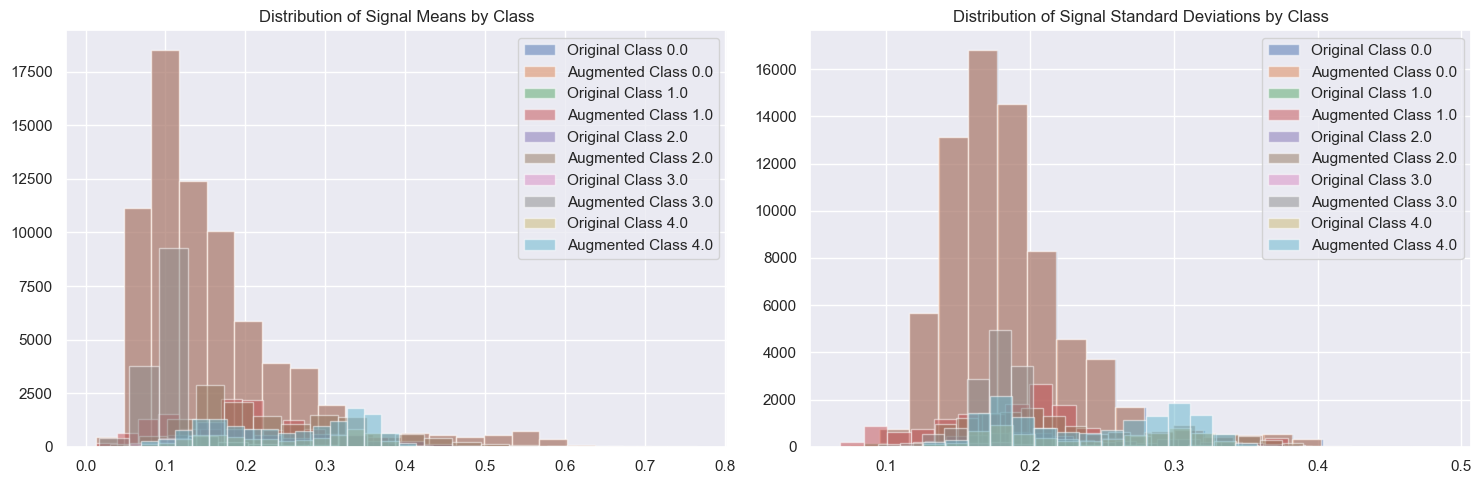

In [ ]:
show_plot = visualize_class_distributions(x_train, X_augmented, y_train, y_augmented)
show_plot

In [ ]:
# split the training data into training and validation data

X_augmented, X_valid, y_augmented, Y_valid = train_test_split(x_train, y_train,  test_size=0.15, stratify=y_train, random_state=42)

In [ ]:
# print the shape of the training and validation data and testing data

print(f"shape of X train is: {X_augmented.shape}")
print(f"shape of Y train is: {y_augmented.shape}")
print(f"shape of X test is: {X_test.shape}")
print(f"shape of Y test is: {Y_test.shape}")
print(f"shape of X valid is: {X_valid.shape}")
print(f"shape of Y valid is: {Y_valid.shape}")

shape of X train is: (74420, 187)
shape of Y train is: (74420,)
shape of X test is: (21892, 187)
shape of Y test is: (21892,)
shape of X valid is: (13134, 187)
shape of Y valid is: (13134,)


In [ ]:
# print the number of samples in each class in the training and validation data and testing data

print(Counter(y_augmented))
print(Counter(Y_test))
print(Counter(Y_valid))

n_classes = len(Counter(y_augmented))
print(f"num of classes : {n_classes}") 

Counter({0.0: 61600, 4.0: 5466, 2.0: 4920, 1.0: 1889, 3.0: 545})
Counter({0.0: 18118, 4.0: 1608, 2.0: 1448, 1.0: 556, 3.0: 162})
Counter({0.0: 10871, 4.0: 965, 2.0: 868, 1.0: 334, 3.0: 96})
num of classes : 5


In [ ]:
# convert the labels to categorical data

Y_train = y_augmented.astype(np.int8)
Y_train = np.array(to_categorical(Y_train))
X_train = np.array(X_augmented)

Y_test = Y_test.astype(np.int8)
Y_test = np.array(to_categorical(Y_test))
X_test = np.array(X_test)

Y_valid = Y_valid.astype(np.int8)
Y_valid = np.array(to_categorical(Y_valid))
X_valid = np.array(X_valid)

In [ ]:
# print the shape of the training and validation data and testing data

print(f"shape of X train is: {X_train.shape}")
print(f"shape of Y train is: {Y_train.shape}")
print(f"shape of X test is: {X_test.shape}")
print(f"shape of Y test is: {Y_test.shape}")
print(f"shape of X valid is: {X_valid.shape}")
print(f"shape of Y valid is: {Y_valid.shape}")

shape of X train is: (74420, 187)
shape of Y train is: (74420, 5)
shape of X test is: (21892, 187)
shape of Y test is: (21892, 5)
shape of X valid is: (13134, 187)
shape of Y valid is: (13134, 5)


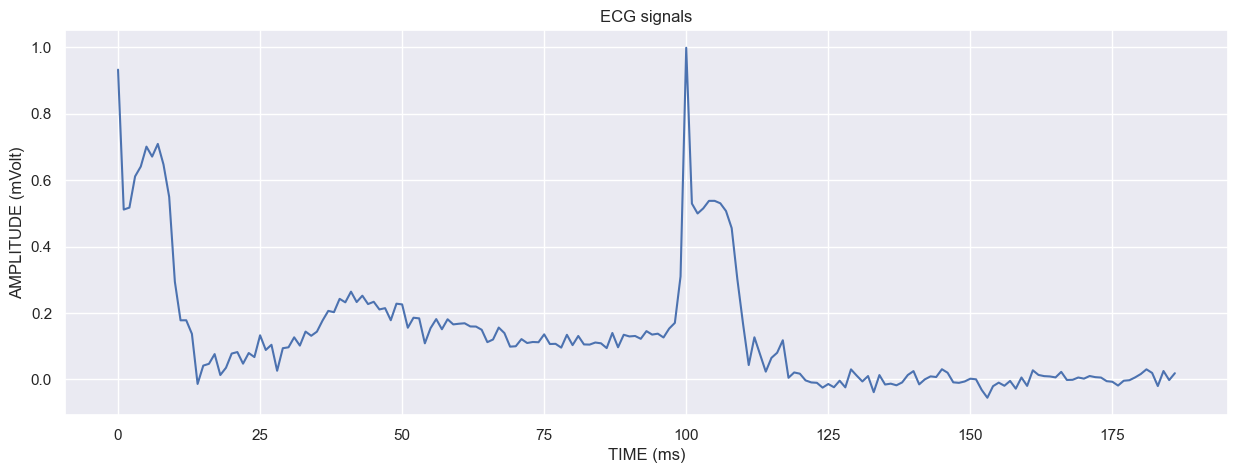

In [ ]:
# visualize an augmented ECG signal in a plot

plt.figure(figsize=(15,5))
plt.title('ECG signals')
plt.xlabel('TIME (ms)')
plt.ylabel('AMPLITUDE (mVolt)')
signals = [100005]
for s in signals:
  plt.plot(X_train[s, 0:187])

In [ ]:
# import the necessary libraries

import h5py
from keras import Input, Model, models, losses, optimizers
from keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, BatchNormalization, Dropout, MaxPool1D, GlobalAveragePooling1D, LeakyReLU,\
ELU, ReLU, Add, Multiply, Reshape
from keras.activations import relu, gelu, elu
from keras.optimizers import Adam, AdamW
from keras_radam import RAdam
from keras.models import Sequential
from keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,\
confusion_matrix, ConfusionMatrixDisplay, classification_report
import pydot
import json, pickle

## 6. Genetic Algorithm Optimization

A Genetic Algorithm (GA) is used to optimize CNN hyperparameters.

Optimized parameters:
- Number of filters
- Kernel size
- Stride
- Dropout rate
- Learning rate

Fitness function considers:
- Accuracy
- F1-score
- Model complexity

In [ ]:

from tensorflow.keras.optimizers import Adam
import keras.backend as K
import logging
import time
from typing import List, Dict, Tuple


class ECGModelGenetics:
    def __init__(self, input_length, num_classes):
        """
        Initialize the genetic algorithm with focus on high-impact parameters
        
        Args:
            input_length: Length of each ECG segment
            num_classes: Number of heartbeat classes
        """
        self.input_length = input_length
        self.num_classes = num_classes
        

        # Default configuration parameters that can be overridden in optimize()
        self.default_config = {
            'population_size' : 10,
            'num_generations' : 20,
            'epochs_per_individual': 10,
            'batch_size' : 32,
            'elite_size' : 2,
            'tournament_size' : 3,
            'patience' : 5,
            #'min_improvement' : 0.001
        }
        
        
        # Setup logging with more detailed format
        logging.basicConfig(
            level=logging.INFO,
            format='%(asctime)s - %(levelname)s - %(message)s',
            datefmt='%Y-%m-%d %H:%M:%S'
        )
        self.logger = logging.getLogger(__name__)
        
        # Remove num_conv_layers from param bounds since it's now fixed
        self.param_bounds = {
            'filters': {                   # Increasing filters with depth
                'layer1': (32, 64),
                'layer2': (64, 128),
            },
            'learning_rate': (0.0001, 0.01),
            'kernel_sizes': [3, 5, 7, 9, 11],
            
            'dropout_rates': [0.2, 0.3, 0.4, 0.5],
            'batch_size': 32,              # Fixed batch size
        }

    def  create_model(self, genome: Dict) -> tf.keras.Model:
        """
        Create a model with exactly 2 conv layers
        
        Args:
            genome: Dictionary containing model architecture parameters
        Returns:
            Compiled Keras model with optimized architecture
        """
        model = Sequential()

        # Ensure genome has required keys
        if not all(key in genome for key in ['filters', 'kernel_sizes', 'dropout_rates']):
            raise ValueError("Genome missing required keys")
        
        # First convolutional layer
        model.add(Conv1D(
            filters=genome['filters'][0],
            kernel_size=(genome['kernel_sizes'][0],), #convert to tuple
            activation='relu',
            input_shape=(self.input_length, 1)
        ))
        model.add(BatchNormalization())
        model.add(MaxPool1D(pool_size=2))
        model.add(Dropout(genome['dropout_rates'][0]))
        
        # Second convolutional layer
        model.add(Conv1D(
            filters=genome['filters'][1],
            kernel_size=genome['kernel_sizes'][1],
            activation='relu'
        ))
        
        # Fixed dense layer configuration
        model.add(Flatten())
        model.add(Dense(units=128, activation='relu'))
        model.add(Dense(self.num_classes, activation='softmax'))
        
        # Compile model with variable learning rate
        optimizer = Adam(learning_rate=genome['learning_rate'])
        model.compile(optimizer=optimizer,
                     loss=losses.categorical_crossentropy,
                     metrics=['accuracy'])
        return model

    def generate_random_genome(self) -> Dict:
        """
        Generate random architecture parameters for 2 conv layers
        
        Returns:
            Dictionary containing valid model parameters
        """
        
        # Generate filters for exactly 2 layers
        filters = [
            np.random.randint(self.param_bounds['filters']['layer1'][0], 
                            self.param_bounds['filters']['layer1'][1]),
            np.random.randint(self.param_bounds['filters']['layer2'][0], 
                            self.param_bounds['filters']['layer2'][1])
        ]
        
        # Generate kernel sizes for 2 layers
        kernel_sizes = np.random.choice(
            self.param_bounds['kernel_sizes'],
            size=2
        ).tolist()
    
        # Generate dropout rates for 2 layers
        dropout_rates = list(np.random.choice(
            self.param_bounds['dropout_rates'],
            size=2
        ))
        
        return {
            'filters': filters,
            'kernel_sizes': kernel_sizes,  
            'dropout_rates': dropout_rates,
            'learning_rate': np.random.uniform(self.param_bounds['learning_rate'][0],
                                             self.param_bounds['learning_rate'][1])
        }

    def crossover(self, parent1: Dict, parent2: Dict) -> Dict:
        """
        Perform crossover while maintaining valid parameter structures
        Implements a more controlled parameter inheritance
        """
        """Perform crossover for 2 fixed layers"""

        # Initialize child genome
        child = {
            'filters': [],
            'kernel_sizes': [],
            'dropout_rates': [],
            'learning_rate': np.random.choice([parent1['learning_rate'], parent2['learning_rate']])
        }
        
        # Crossover for each layer
        for i in range(2):
            # Inherit filters
            child['filters'].append(
                parent1['filters'][i] if np.random.random() < 0.5 
                else parent2['filters'][i]
            )

            # Inherit kernel sizes
            child['kernel_sizes'].append(
                parent1['kernel_sizes'][i] if np.random.random() < 0.5 
                else parent2['kernel_sizes'][i]
            )

            # Inherit dropout rates
            child['dropout_rates'].append(
                parent1['dropout_rates'][i] if np.random.random() < 0.5 
                else parent2['dropout_rates'][i]
            )
        
        return child
        

    def mutate(self, genome: Dict) -> Dict:
        """Mutate genome for 2 fixed layers"""
        mutated = genome.copy()
        
        # Mutate parameters for each layer
        for i in range(2):
            # Mutate filters (20% chance)
            if np.random.random() < 0.2:
                layer_key = f'layer{i+1}'
                filter_range = self.param_bounds['filters'][layer_key]
                current_filters = mutated['filters'][i]
                delta = np.random.randint(-32, 33)
                mutated['filters'][i] = max(
                    filter_range[0],
                    min(filter_range[1], current_filters + delta)
                )
            
            # Mutate kernel sizes (20% chance)
            if np.random.random() < 0.2:
                current_kernel = mutated['kernel_sizes'][i]
                available_kernels = [
                    k for k in self.param_bounds['kernel_sizes'] 
                    if abs(k - current_kernel) <= 2
                ]
                if available_kernels:
                    mutated['kernel_sizes'][i] = np.random.choice(available_kernels)
            
            # Mutate dropout rates (20% chance)
            if np.random.random() < 0.2:
                current_rate = mutated['dropout_rates'][i]
                delta = np.random.uniform(-0.1, 0.1)
                new_rate = max(0.1, min(0.5, current_rate + delta))
                mutated['dropout_rates'][i] = round(new_rate, 2)
        
        # Learning rate mutation (20% chance)
        if np.random.random() < 0.2:
            current_lr = mutated['learning_rate']
            multiplier = np.random.uniform(0.5, 2.0)
            new_lr = current_lr * multiplier
            mutated['learning_rate'] = max(
                self.param_bounds['learning_rate'][0],
                min(self.param_bounds['learning_rate'][1], new_lr)
            )
        
        return mutated
    
    def optimize(self, X_train, Y_train, x_valid=None, y_valid=None, 
                population_size=None, generations=None, epochs_per_individual=None,
                batch_size=32, validation_split=0.2) -> Tuple[Dict, float]:
        """
        Main optimization function that runs the genetic algorithm
        
        Args:
            X_train: Training data
            Y_train: Training labels
            x_valid: Optional validation data (if None, will split from training data)
            y_valid: Optional validation labels
            population_size: Size of population per generation
            num_generations: Number of generations to evolve
            epochs_per_individual: Number of epochs to train each model
            batch_size: Batch size for training
            validation_split: Validation split ratio if X_valid not provided
            
        Returns:
            Tuple containing the best genome and its fitness score
        """
        # Override default configuration with provided values
        self.population_size = population_size or self.default_config['population_size']
        self.num_generations = generations or self.default_config['num_generations']
        epochs = epochs_per_individual or self.default_config['epochs_per_individual']
        self.param_bounds['batch_size'] = batch_size or self.default_config['batch_size']
        #self.min_improvement = self.default_config['min_improvement']
        self.tournament_size = self.default_config['tournament_size']
        

        # Prepare validation data if not provided
        if x_valid is None or y_valid is None:
            split_idx = int(len(X_train) * (1 - validation_split))
            x_valid = X_train[split_idx:]
            y_valid = Y_train[split_idx:]
            X_train = X_train[:split_idx]
            Y_train = Y_train[:split_idx]
        

        # Initialize population and tracking variables
        population = [self.generate_random_genome() for _ in range(self.population_size)]
        best_fitness = float('-inf')
        best_genome = None
        generations_without_improvement = 0

        self.logger.info("Starting genetic optimization")
        
        # Initialize tracking for best parameters
        best_params_history = []

        # Generation loop
        for generation in range(self.num_generations):
            start_time = time.time()

            self.logger.info(f"\n{'='*50}")
            self.logger.info(f"Starting Generation {generation + 1}/{self.num_generations}")
            self.logger.info(f"{'='*50}\n")
            
            # step1: Evaluate fitness for all genomes in current population
            fitness_scores = []
            generation_best_fitness = float('-inf')
            generation_best_params = None
            
            for idx, genome in enumerate(population):
                self.logger.info(f"\nEvaluating Individual {idx + 1}/{self.population_size}")
                fitness = self.evaluate_fitness(genome, X_train, Y_train, x_valid, y_valid, epochs)
                fitness_scores.append(fitness)

                # Track best in this generation
                if fitness > generation_best_fitness:
                    generation_best_fitness = fitness
                    generation_best_params = genome.copy()
            
            
            # step2: update best overall
            current_best_idx = np.argmax(fitness_scores)
            current_best_fitness = fitness_scores[current_best_idx]
            
            if current_best_fitness > best_fitness:
                best_fitness = current_best_fitness
                best_genome = population[current_best_idx].copy()
                generations_without_improvement = 0

                # Track the improvement in parameters
                best_params_history.append({
                    'generation': generation + 1,
                    'fitness': best_fitness,
                    'params': best_genome.copy()
                })

                self.logger.info("\nNew Best Model Found!")
                self.logger.info(f"\nNew best fitness: {best_fitness:.4f}")
                self._log_parameter_comparison(best_params_history)
            else:
                generations_without_improvement += 1
            
            # Generation summary
            generation_time = time.time() - start_time
            self._log_generation_summary(
                generation + 1,
                generation_best_fitness,
                best_fitness,
                generation_time,
                generation_best_params
            )
            
            # Early stopping check
            if generations_without_improvement >= self.default_config['patience']:
                self.logger.info(f"Early stopping triggered after {generation + 1} generations")
                break
            
            # Create next generation
            population = self.create_next_generation(population, fitness_scores)
            
        self._log_final_summary(best_genome, best_fitness, best_params_history)  
          
        return best_genome, best_fitness
    
    def _log_parameter_comparison(self, history):
        """
        Log comparison of parameters between improvements
        """
        if len(history) >= 2:
            current = history[-1]
            previous = history[-2]
        
            self.logger.info("\nParameter Changes from Previous Best:")
            self.logger.info(f"Generation {previous['generation']} -> {current['generation']}")
            self.logger.info(f"Fitness Improvement: {previous['fitness']:.4f} -> {current['fitness']:.4f}")
        
            # Compare parameters
            current_params = current['params']
            previous_params = previous['params']
        
        
            # Compare layer parameters
            
            for i in range(2):
                if (current_params['filters'][i] != previous_params['filters'][i] or
                    current_params['kernel_sizes'][i] != previous_params['kernel_sizes'][i] or
                    current_params['dropout_rates'][i] != previous_params['dropout_rates'][i]):
                    self.logger.info(f"\nLayer {i+1} changes:")
                    self.logger.info(f"  Filters: {previous_params['filters'][i]} -> {current_params['filters'][i]}")
                    self.logger.info(f"  Kernel Size: {previous_params['kernel_sizes'][i]} -> {current_params['kernel_sizes'][i]}")
                    self.logger.info(f"  Dropout: {previous_params['dropout_rates'][i]:.2f} -> {current_params['dropout_rates'][i]:.2f}")
        
            if abs(current_params['learning_rate'] - previous_params['learning_rate']) > 1e-6:
                self.logger.info(f"\nLearning Rate: {previous_params['learning_rate']:.6f} -> {current_params['learning_rate']:.6f}")

    def _log_generation_summary(self, generation, gen_best_fitness, overall_best_fitness, 
                          generation_time, gen_best_params):
        """
        Log detailed generation summary
        """
        self.logger.info(f"\nGeneration {generation} Summary:")
        self.logger.info(f"Best fitness this generation: {gen_best_fitness:.4f}")
        self.logger.info(f"Overall best fitness: {overall_best_fitness:.4f}")
        self.logger.info(f"Generation time: {generation_time:.2f}s")
    
        if gen_best_params:
            self.logger.info("\nBest Parameters This Generation:")
            for i in range(2):
                self.logger.info(f"\nLayer {i+1}:")
                self.logger.info(f"  Filters: {gen_best_params['filters'][i]}")
                self.logger.info(f"  Kernel Size: {gen_best_params['kernel_sizes'][i]}")
                self.logger.info(f"  Dropout Rate: {gen_best_params['dropout_rates'][i]:.2f}")
            self.logger.info(f"\nLearning Rate: {gen_best_params['learning_rate']:.6f}")


    def _log_final_summary(self, best_genome, best_fitness, history):
        """
        Log final optimization summary
        """
        self.logger.info("\nFinal Optimization Results:")
        self.logger.info("=" * 50)
        self.logger.info(f"Best Validation Accuracy: {best_fitness:.4f}")
        self.logger.info("\nBest Model Architecture:")
        
    
        for i in range(2):
            self.logger.info(f"\nLayer {i+1}:")
            self.logger.info(f"  Filters: {best_genome['filters'][i]}")
            self.logger.info(f"  Kernel Size: {best_genome['kernel_sizes'][i]}")
            self.logger.info(f"  Dropout Rate: {best_genome['dropout_rates'][i]:.2f}")
    
        self.logger.info(f"\nLearning Rate: {best_genome['learning_rate']:.6f}")
    
        # Log improvement history
        self.logger.info("\nImprovement History:")
        for entry in history:
            self.logger.info(f"Generation {entry['generation']}: {entry['fitness']:.4f}")


    def evaluate_fitness(self, genome, X_train, Y_train, x_valid, y_valid, epochs):
        """
        Evaluate the fitness of a genome by training and validating the model
        
        Args:
            genome: Dictionary containing model parameters
            X_train: Training data
            Y_train: Training labels
            x_val: Validation data
            y_val: Validation labels
            epochs: Number of training epochs
            
        Returns:
            Validation accuracy as the fitness score
        """

        try:
            # Log detailed architecture information
            self.logger.info("\nModel Architecture Details:")
            self.logger.info("-" * 40)

            # Log layer-specific parameters
            for i in range(2):
                self.logger.info(f"\nLayer {i+1}:")
                self.logger.info(f"  Filters: {genome['filters'][i]}")
                self.logger.info(f"  Kernel Size: {genome['kernel_sizes'][i]}")
                self.logger.info(f"  Dropout Rate: {genome['dropout_rates'][i]:.2f}")
        
            self.logger.info(f"\nLearning Rate: {genome['learning_rate']:.6f}")
            self.logger.info("-" * 40)     

            # Create and train model
            model = self.create_model(genome)
            
            callbacks = [
                EarlyStopping(
                    monitor='val_accuracy',
                    patience=5,
                    restore_best_weights=True,
                    verbose=1
                )   
            ]
            
            # Train model
            history = model.fit(
                X_train, Y_train,
                epochs=epochs,
                batch_size=self.param_bounds['batch_size'],
                validation_data=(x_valid, y_valid),
                callbacks=callbacks,
                verbose=1
            )
            
            # Get the best validation accuracy
            best_val_acc = max(history.history['val_accuracy'])

            # Log the performance summary
            self.logger.info("\nPerformance Summary:")
            self.logger.info(f"Best Validation Accuracy: {best_val_acc:.4f}")
            
            # Clear the model from memory
            del model
            tf.keras.backend.clear_session()
            
        
            # Return best validation accuracy achieved
            return best_val_acc
            
        except Exception as e:
            self.logger.warning(f"Error during fitness evaluation: {str(e)}")
            return float('-inf')
    
    def create_next_generation(self, population: List[Dict], fitness_scores: List[float]) -> List[Dict]:
        """
        Create the next generation through selection, crossover, and mutation
        """
        next_population = []
        
        # Elitism: Keep the best individuals
        elite_size = self.default_config['elite_size']
        sorted_indices = np.argsort(fitness_scores)[::-1]
        for i in range(elite_size):
            next_population.append(population[sorted_indices[i]].copy())
        
        # Fill rest of population through tournament selection, crossover, and mutation
        while len(next_population) < self.population_size:
            # Select parents through tournament selection
            parent1 = self.tournament_select(population, fitness_scores)
            parent2 = self.tournament_select(population, fitness_scores)

            # Perform crossover
            if np.random.random() < 0.8:  # 80% chance of crossover
                child = self.crossover(parent1, parent2)
            else:
                child = parent1.copy()  # Sometimes just copy a parent
            
            # Perform mutation
            if np.random.random() < 0.2:  # 20% chance of mutation
                child = self.mutate(child)

            next_population.append(child)
        
        return next_population

    def tournament_select(self, population: List[Dict], fitness_scores: List[float]) -> Dict:
        """
        Select a genome using tournament selection
        
        Args:
            population: List of genomes
            fitness_scores: List of corresponding fitness scores
            
        Returns:
            Selected genome
        """
        # Randomly select candidates for tournament
        tournament_indices = np.random.choice(
            len(population),
            size=self.tournament_size, #usually 3-5 individuals
            replace=False
        )
        
        # Select the best from tournament
        tournament_fitness = [fitness_scores[i] for i in tournament_indices]
        winner_idx = tournament_indices[np.argmax(tournament_fitness)]
        
        return population[winner_idx].copy()

In [ ]:

class EnhancedECGModelGenetics(ECGModelGenetics):
    def __init__(self, input_length, num_classes, checkpoint_dir='checkpoints'):
        super().__init__(input_length, num_classes)
        self.checkpoint_dir = checkpoint_dir
        os.makedirs(checkpoint_dir, exist_ok=True)
        
        # Enhanced parameter bounds for 2 layers
        self.param_bounds.update({
            'use_residual': [True, True], # Only layer 2 can have residual connection
            'use_se_block': [True, True], # Only layer 2 can have SE block
            'stride_sizes': [1, 2],
            'use_focal_loss': [False, False],  #False when using balanced dataset
            'focal_gamma': [2.0, 3.0, 4.0]
        })

        # Add mutation rates for better control
        self.mutation_rates = {
            'filters': 0.3,
            'kernel_sizes': 0.3,
            'dropout_rates': 0.3,
            'learning_rate': 0.3,
            'use_residual': 0.3,
            'use_se_block': 0.3,
            'stride_sizes': 0.3,
            'use_focal_loss': 0.2,
            'focal_gamma': 0.2
        }

        # Tracking population diversity
        self.population_diversity_metrics = {
            'gene_variance': [],
            'unique_genomes': [],
            'feature_distribution': {}
        }

    def create_model(self, genome: Dict) -> tf.keras.Model:
        """Enhanced model creation with residual connections and SE blocks"""
        inputs = Input(shape=(self.input_length, 1))
        x = inputs
        
        # Store first layer output for potential residual connection
        first_layer_output = None
        

        # First convolutional layer
        conv = Conv1D(
            filters=genome['filters'][0],
            kernel_size=(genome['kernel_sizes'][0],), #convert to tuple
            strides=(genome['stride_sizes'][0],), #convert to tuple
            padding='same'
        )(x)
        
        x = ReLU()(conv)
        x = BatchNormalization()(x)    
         
        
               
        x = MaxPool1D(pool_size=2)(x)
        x = Dropout(genome['dropout_rates'][0])(x)
        first_layer_output = x

        # Second convolutional layer
        conv = Conv1D(
            filters=genome['filters'][1],
            kernel_size=(genome['kernel_sizes'][1],), #convert to tuple
            strides=(genome['stride_sizes'][1],), #convert to tuple
            padding='same'
        )(x)

        x = ReLU()(conv)
        x = BatchNormalization()(x)
        
       

        if genome['use_se_block'][1]:
            x = self._squeeze_excitation_block(x)
        
        # Add residual connection if specified and shapes match
        if genome['use_residual'][1]:
            if K.int_shape(x)[1:] == K.int_shape(first_layer_output)[1:]:
                x = Add()([x, first_layer_output])

        x = MaxPool1D(pool_size=2)(x)
        x = Dropout(genome['dropout_rates'][1])(x)
        
        x = Flatten()(x)
        x = Dense(128, activation='relu')(x)
        outputs = Dense(self.num_classes, activation='softmax')(x)
        
        model = Model(inputs=inputs, outputs=outputs)
        
        # Fixed Adam optimizer
        optimizer = Adam(learning_rate=genome['learning_rate'])
        
        # Configure loss
        if genome['use_focal_loss']:
            loss = losses.CategoricalFocalCrossentropy(
                alpha=0.25,
                gamma=genome['focal_gamma']
            )
        else:
            loss = 'categorical_crossentropy'
        
        # Create F1Score metric instance outside of the training function
        f1_metric = tf.keras.metrics.F1Score(
            average='macro',
            threshold=None,
            name='macro_f1'
        )
        
        model.compile(
            optimizer=optimizer,
            loss=loss,
            metrics=['accuracy', f1_metric]
        )
        
        return model
    
    def _squeeze_excitation_block(self, input_tensor, reduction_ratio=16):
        """Squeeze and Excitation block for feature recalibration"""
        filters = input_tensor.shape[-1]
        se_shape = (1, filters)
        
        # Squeeze
        x = GlobalAveragePooling1D()(input_tensor)
        x = Reshape(se_shape)(x)
        
        # Excitation
        x = Dense(filters // reduction_ratio, activation='relu')(x)
        x = Dense(filters, activation='sigmoid')(x)
        
        # Scale
        return Multiply()([input_tensor, x])
    
    def evaluate_fitness(self, genome, X_train, Y_train, x_valid, y_valid, epochs):
        """Enhanced fitness evaluation with multiple objectives"""
        try:
            model = self.create_model(genome)
        
            # Calculate model complexity
            trainable_params = np.sum([K.count_params(w) for w in model.trainable_weights])
        
            # Train and evaluate
            start_time = time.time()
            history = model.fit(
                X_train, Y_train,
                epochs=epochs,
                batch_size=self.param_bounds['batch_size'],
                validation_data=(x_valid, y_valid),
                callbacks=[
                    EarlyStopping(
                            monitor='val_accuracy',  # Changed to monitor the custom metric
                            patience=5,
                            restore_best_weights=True,
                            mode='max'  # Specify that higher is better
                        )
                ],
                verbose=1
            )
            training_time = time.time() - start_time
        
            # Get best metrics
            best_val_acc = max(history.history['val_accuracy'])
            best_val_f1 = max(history.history['val_macro_f1'])
        
            # Calculate final fitness score
            complexity_penalty = 1.0 / (1.0 + np.log(trainable_params))
            time_penalty = 1.0 / (1.0 + np.log(training_time))
        
            fitness = (
                0.4 * best_val_acc+
                0.4 * best_val_f1 +
                0.1 * complexity_penalty +
                0.1 * time_penalty
            )
        
            # Clear the model from memory
            del model
            tf.keras.backend.clear_session()

            return fitness
        except Exception as e:
            self.logger.warning(f"Error during fitness evaluation: {str(e)}")
            return float('-inf')
        
    def generate_random_genome(self) -> Dict:
        """Generate random genome with enhanced parameters"""
        genome = super().generate_random_genome()
        
        # Generate enhanced parameters with correct sizes for 2 layers
        genome.update({
            'use_residual': [False, True],  # First layer can't have residual--Always True for second layer
            'use_se_block': [False, True],  # Not using SE for first layer --- Always True for second layer
            'stride_sizes': [
                np.random.choice(self.param_bounds['stride_sizes']),
                np.random.choice(self.param_bounds['stride_sizes'])
            ],
            'use_focal_loss': np.random.choice(self.param_bounds['use_focal_loss']),
            'focal_gamma': np.random.choice(self.param_bounds['focal_gamma'])
        })
        
        return genome

    def crossover(self, parent1: Dict, parent2: Dict) -> Dict:
        """Enhanced crossover with proper parameter handling"""
        # Get basic parameters from parent class crossover
        child = super().crossover(parent1, parent2)
        
        # Crossover enhanced parameters for 2 layers
        child.update({
            'use_residual': [False] + [parent1['use_residual'][1] if np.random.random() < 0.5 else parent2['use_residual'][1]],
            'use_se_block': [False] + [parent1['use_se_block'][1] if np.random.random() < 0.5 else parent2['use_se_block'][1]],
            'stride_sizes': [
                parent1['stride_sizes'][i] if np.random.random() < 0.5 else parent2['stride_sizes'][i]
                for i in range(2)
            ],
            'use_focal_loss': parent1['use_focal_loss'] if np.random.random() < 0.5 else parent2['use_focal_loss'],
            'focal_gamma': parent1['focal_gamma'] if np.random.random() < 0.5 else parent2['focal_gamma']
        })
        
        return child

    def mutate(self, genome: Dict) -> Dict:
        """Enhanced mutation with higher mutation rates and proper handling of parameters"""
        """Mutate genome for exactly 2 layers"""
        # Create a deep copy to avoid modifying the original
        mutated = {k: v.copy() if isinstance(v, list) else v for k, v in genome.items()}
        
        # Mutate parameters for each layer
        for i in range(2):
            # Mutate filters
            if np.random.random() < self.mutation_rates['filters']:
                layer_key = f'layer{i+1}'
                filter_range = self.param_bounds['filters'][layer_key]
                delta = np.random.randint(-32, 33)
                mutated['filters'][i] = max(filter_range[0],
                                         min(filter_range[1],
                                             mutated['filters'][i] + delta))
            
            # Mutate other layer-specific parameters
            if i == 1:  # Only second layer can have residual and SE block
                if np.random.random() < self.mutation_rates['use_residual']:
                    mutated['use_residual'][i] = np.random.choice(self.param_bounds['use_residual'])
                
                if np.random.random() < self.mutation_rates['use_se_block']:
                    mutated['use_se_block'][i] = np.random.choice(self.param_bounds['use_se_block'])
            
            # Mutate kernel sizes
            if np.random.random() < self.mutation_rates['kernel_sizes']:
                mutated['kernel_sizes'][i] = np.random.choice(self.param_bounds['kernel_sizes'])
            
            # Mutate dropout rates
            if np.random.random() < self.mutation_rates['dropout_rates']:
                current_rate = mutated['dropout_rates'][i]
                delta = np.random.uniform(-0.1, 0.1)
                mutated['dropout_rates'][i] = max(0.1, min(0.5, current_rate + delta))
            
            
            # Mutate stride_sizes
            if np.random.random() < self.mutation_rates['stride_sizes']:
                mutated['stride_sizes'][i] = np.random.choice(self.param_bounds['stride_sizes'])
        
        # Mutate learning rate
        if np.random.random() < self.mutation_rates['learning_rate']:
            multiplier = np.random.uniform(0.5, 2.0)
            mutated['learning_rate'] = max(self.param_bounds['learning_rate'][0],
                                         min(self.param_bounds['learning_rate'][1],
                                             mutated['learning_rate'] * multiplier))
        
        # Mutate global parameters
        if np.random.random() < self.mutation_rates['use_focal_loss']:
            mutated['use_focal_loss'] = np.random.choice(self.param_bounds['use_focal_loss'])
        
        if np.random.random() < self.mutation_rates['focal_gamma']:
            mutated['focal_gamma'] = np.random.choice(self.param_bounds['focal_gamma'])
        
        return mutated

    def optimize(self, X_train, Y_train, x_valid=None, y_valid=None, 
                population_size=None, generations=None, epochs_per_individual=None,
                batch_size=None, validation_split=0.2, resume_checkpoint=None) -> Tuple[Dict, float]:
        """
        Enhanced optimize method with checkpoint resumption and diversity tracking
        
        Args:
            resume_checkpoint: Optional path to checkpoint file to resume from
        """
        # Override default configuration with provided values
        self.population_size = population_size or self.default_config['population_size']
        self.num_generations = generations or self.default_config['num_generations']
        epochs = epochs_per_individual or self.default_config['epochs_per_individual']
        self.param_bounds['batch_size'] = batch_size or self.default_config['batch_size']
        self.tournament_size = self.default_config['tournament_size']
        
        # Initialize population and tracking variables
        population = [self.generate_random_genome() for _ in range(self.population_size)]
        best_fitness = float('-inf')
        best_genome = None
        generations_without_improvement = 0
        best_params_history = []
        generation_metrics = []

        # Checkpoint saving logic within the method
        def periodic_checkpoint(generation, population, best_genome, best_fitness):
            """Save checkpoint after each generation."""
            self.save_checkpoint(generation, population, best_genome, best_fitness)

        # Resume from checkpoint if provided
        if resume_checkpoint:
            try:
                start_generation, population, best_genome, best_fitness = self.load_checkpoint(resume_checkpoint)
                self.logger.info(f"Resuming optimization from generation {start_generation}")
            except Exception as e:
                self.logger.warning(f"Failed to load checkpoint: {e}")
                start_generation = 0
                population = [self.generate_random_genome() for _ in range(self.population_size)]
                best_genome = None
                best_fitness = float('-inf')
        else:
            start_generation = 0
            population = [self.generate_random_genome() for _ in range(self.population_size)]
            best_genome = None
            best_fitness = float('-inf')
    
        # Setup enhanced logging
        self.logger.info("Starting Enhanced ECG Model Optimization")
        self.logger.info("\nOptimizing Parameters:")
        self.logger.info("- Number of convolutional layers")
        self.logger.info("- Filter sizes")
        self.logger.info("- Kernel sizes")
        self.logger.info("- Dropout rates")
        self.logger.info("- Learning rate")
        self.logger.info("- Residual connections")
        self.logger.info("- Squeeze-and-Excitation blocks")
        self.logger.info("- Stride sizes")
        self.logger.info("- Focal loss parameters")


        # Generation loop
        for generation in range(start_generation, self.num_generations):
            start_time = time.time()
        
            self.logger.info(f"\n{'='*50}")
            self.logger.info(f"Starting Generation {generation + 1}/{self.num_generations}")
            self.logger.info(f"{'='*50}\n")
        
            # Evaluate fitness for all genomes in current population
            fitness_scores = []
            generation_best_fitness = float('-inf')
            generation_best_params = None
            generation_avg_fitness = 0

            for idx, genome in enumerate(population):
                self.logger.info(f"\nEvaluating Individual {idx + 1}/{self.population_size}")
                fitness = self.evaluate_fitness(genome, X_train, Y_train, x_valid, y_valid, epochs)
                fitness_scores.append(fitness)
                generation_avg_fitness += fitness

                if fitness > generation_best_fitness:
                    generation_best_fitness = fitness
                    generation_best_params = genome.copy()
            
            generation_avg_fitness /= self.population_size

            # Update best overall
            current_best_idx = np.argmax(fitness_scores)
            current_best_fitness = fitness_scores[current_best_idx]
        
            if current_best_fitness > best_fitness:
                best_fitness = current_best_fitness
                best_genome = population[current_best_idx].copy()
                generations_without_improvement = 0

                best_params_history.append({
                    'generation': generation + 1,
                    'fitness': best_fitness,
                    'params': best_genome.copy()
                })

                self.logger.info("\nNew Best Model Found!")
                self.logger.info(f"New best fitness: {best_fitness:.4f}")
                self._log_parameter_comparison(best_params_history)
            else:
                generations_without_improvement += 1

            # Store generation metrics
            generation_metrics.append({
                'generation': generation + 1,
                'best_fitness': generation_best_fitness,
                'avg_fitness': generation_avg_fitness,
                'overall_best_fitness': best_fitness
            })

            # Generation summary
            generation_time = time.time() - start_time
            self._log_generation_summary(
                generation + 1,
                generation_metrics[-1],
                generation_time,
                generation_best_params
            )

            # Early stopping check
            if generations_without_improvement >= self.default_config['patience']:
                self.logger.info(f"\nEarly stopping triggered after {generation + 1} generations")
                break

            # Create next generation
            population = self.create_next_generation(population, fitness_scores)

            # Calculate and log population diversity
            diversity_metrics = self.calculate_population_diversity(population)
            self.logger.info("\nPopulation Diversity Metrics:")
            self.logger.info(f"Unique Genomes: {diversity_metrics['unique_genomes']}")
            self.logger.info("Gene Variances:")
            for param, variance in diversity_metrics['gene_variance'].items():
                self.logger.info(f"  {param}: {variance:.4f}")
            self.logger.info("Feature Distributions:")
            for param, dist in diversity_metrics['feature_distribution'].items():
                self.logger.info(f"  {param}: {dist}")
            
            # Save checkpoint after each generation
            periodic_checkpoint(generation + 1, population, best_genome, best_fitness)
        
        self._log_final_summary(best_genome, best_fitness, best_params_history, generation_metrics)
        
        # Final checkpoint
        periodic_checkpoint(generation, population, best_genome, best_fitness)
        
        return best_genome, best_fitness

    def _log_parameter_comparison(self, history):
        """Override parameter comparison logging to include new parameters"""
        super()._log_parameter_comparison(history)
        
        if len(history) >= 2:
            current = history[-1]
            previous = history[-2]
            
            # Log new parameter changes
            self.logger.info("\nAdditional Parameter Changes:")
            current_params = current['params']
            previous_params = previous['params']
            
            for i in range(2):
                self.logger.info(f"\nLayer {i+1} Additional Parameters:")
                self.logger.info(f"  Residual: {previous_params['use_residual'][i]} -> {current_params['use_residual'][i]}")
                self.logger.info(f"  SE Block: {previous_params['use_se_block'][i]} -> {current_params['use_se_block'][i]}")
                self.logger.info(f"  Stride: {previous_params['stride_sizes'][i]} -> {current_params['stride_sizes'][i]}")
            
            self.logger.info(f"\nGlobal Parameters:")
            self.logger.info(f"  Focal Loss: {previous_params['use_focal_loss']} -> {current_params['use_focal_loss']}")
            self.logger.info(f"  Focal Gamma: {previous_params['focal_gamma']} -> {current_params['focal_gamma']}")
    

    def _log_generation_summary(self, generation, metrics, generation_time, gen_best_params):
        """Enhanced generation summary logging"""
        self.logger.info(f"\nGeneration {generation} Summary:")
        self.logger.info(f"Best fitness this generation: {metrics['best_fitness']:.4f}")
        self.logger.info(f"Average fitness this generation: {metrics['avg_fitness']:.4f}")
        self.logger.info(f"Overall best fitness: {metrics['overall_best_fitness']:.4f}")
        self.logger.info(f"Generation time: {generation_time:.2f}s")

        if gen_best_params:
            self.logger.info("\nBest Parameters This Generation:")
            for i in range(2):
                self.logger.info(f"\nLayer {i+1}:")
                self.logger.info(f"  Filters: {gen_best_params['filters'][i]}")
                self.logger.info(f"  Kernel Size: {gen_best_params['kernel_sizes'][i]}")
                self.logger.info(f"  Dropout Rate: {gen_best_params['dropout_rates'][i]:.2f}")
                self.logger.info(f"  Residual: {gen_best_params['use_residual'][i]}")
                self.logger.info(f"  SE Block: {gen_best_params['use_se_block'][i]}")
                self.logger.info(f"  Stride: {gen_best_params['stride_sizes'][i]}")
        
            self.logger.info(f"\nLearning Rate: {gen_best_params['learning_rate']:.6f}")
            self.logger.info(f"Focal Loss: {gen_best_params['use_focal_loss']}")
            self.logger.info(f"Focal Gamma: {gen_best_params['focal_gamma']}")
    
    def _log_final_summary(self, best_genome, best_fitness, history, generation_metrics):
        """Enhanced final summary logging with performance trends"""
        self.logger.info("\nFinal Optimization Results:")
        self.logger.info("=" * 50)
        self.logger.info(f"Best Validation Accuracy: {best_fitness:.4f}")
    
        # Log best model architecture
        self.logger.info("\nBest Model Architecture:")

        for i in range(2):
            self.logger.info(f"\nLayer {i+1}:")
            self.logger.info(f"  Filters: {best_genome['filters'][i]}")
            self.logger.info(f"  Kernel Size: {best_genome['kernel_sizes'][i]}")
            self.logger.info(f"  Dropout Rate: {best_genome['dropout_rates'][i]:.2f}")
            self.logger.info(f"  Residual: {best_genome['use_residual'][i]}")
            self.logger.info(f"  SE Block: {best_genome['use_se_block'][i]}")
            self.logger.info(f"  Stride: {best_genome['stride_sizes'][i]}")

        self.logger.info(f"\nLearning Rate: {best_genome['learning_rate']:.6f}")
        self.logger.info(f"Focal Loss: {best_genome['use_focal_loss']}")
        self.logger.info(f"Focal Gamma: {best_genome['focal_gamma']}")

        # Log improvement history
        self.logger.info("\nImprovement History:")
        for entry in history:
            self.logger.info(f"Generation {entry['generation']}: {entry['fitness']:.4f}")

        # Log performance trends
        self.logger.info("\nPerformance Trends:")
        generations = [m['generation'] for m in generation_metrics]
        avg_fitness = [m['avg_fitness'] for m in generation_metrics]
        best_fitness_trend = [m['best_fitness'] for m in generation_metrics]
    
        self.logger.info(f"Initial generation average fitness: {avg_fitness[0]:.4f}")
        self.logger.info(f"Final generation average fitness: {avg_fitness[-1]:.4f}")
        self.logger.info(f"Best fitness improvement: {best_fitness_trend[0]:.4f} -> {best_fitness_trend[-1]:.4f}")
    
        # Calculate improvement rates
        if len(generations) > 1:
            avg_improvement_rate = (avg_fitness[-1] - avg_fitness[0]) / len(generations)
            best_improvement_rate = (best_fitness_trend[-1] - best_fitness_trend[0]) / len(generations)
            self.logger.info(f"Average improvement rate per generation: {avg_improvement_rate:.4f}")
            self.logger.info(f"Best fitness improvement rate per generation: {best_improvement_rate:.4f}")
        
    def calculate_population_diversity(self, population):
        """
        Calculate and log population diversity metrics
    
        Args:
            population: List of genomes in current generation
    
        Returns:
            Dictionary of diversity metrics
        """
        # Variance of numeric parameters
        numeric_params = ['filters', 'learning_rate', 'dropout_rates']
        gene_variances = {}
    
        for param in numeric_params:
            param_values = [
                genome[param] if param != 'dropout_rates' 
                else np.mean(genome[param]) 
                for genome in population
            ]
            gene_variances[param] = np.var(param_values)


        # Unique genomes - convert lists to tuples for hashability
        def make_hashable(value):
            if isinstance(value, list):
                return tuple(make_hashable(item) for item in value)
            elif isinstance(value, dict):
                return tuple((k, make_hashable(v)) for k, v in sorted(value.items()))
            else:
                return value

        # Unique genomes - convert to hashable types
        unique_genomes = len(set(make_hashable(genome) for genome in population))
    
        # Feature distribution tracking
        feature_distribution = {}
        categorical_params = ['use_residual', 'use_se_block', 'use_focal_loss']
    
        for param in categorical_params:
            feature_distribution[param] = {}
            for genome in population:
                # Convert list values to tuples for hashability
                value = tuple(genome[param]) if isinstance(genome[param], list) else genome[param]
                feature_distribution[param][value] = feature_distribution[param].get(value, 0) + 1
    
        # Store metrics (optional, depending on your needs)
        if not hasattr(self, 'diversity_history'):
            self.diversity_history = []
    
        self.diversity_history.append({
            'gene_variance': gene_variances,
            'unique_genomes': unique_genomes,
            'feature_distribution': feature_distribution
        })
    
        diversity_metrics = {
            'gene_variance': gene_variances,
            'unique_genomes': unique_genomes,
            'feature_distribution': feature_distribution
        }
    
        return diversity_metrics
    
    def save_checkpoint(self, generation, population, best_genome, best_fitness):
        """
        Save optimization state for later resumption using Pickle
        
        Args:
            generation: Current generation number
            population: Current population of genomes
            best_genome: Best performing genome
            best_fitness: Fitness of best genome
        """
        
        checkpoint = {
            'generation': generation,
            'population': population,
            'best_genome': best_genome,
            'best_fitness': best_fitness,
            'population_diversity': self.population_diversity_metrics
        }
        
        # Ensure checkpoint directory exists
        os.makedirs(self.checkpoint_dir, exist_ok=True)

        checkpoint_path = os.path.join(
            self.checkpoint_dir, 
            f'checkpoint_gen_{generation}.pkl'
        )
        
        with open(checkpoint_path, 'wb') as f:  # Use 'wb' mode for binary writing
            pickle.dump(checkpoint, f)
        
        self.logger.info(f"Checkpoint saved: {checkpoint_path}")
    
    def load_checkpoint(self, checkpoint_path):
        """
        Load a previously saved checkpoint using pickle
        
        Args:
            checkpoint_path: Path to checkpoint file
        
        Returns:
            Tuple of (generation, population, best_genome, best_fitness)
        """
        with open(checkpoint_path, 'rb') as f: # Use 'rb' mode for binary reading
            checkpoint = pickle.load(f)

        # Restore population and best genome
        population = checkpoint['population']
        best_genome = checkpoint['best_genome']
        best_fitness = checkpoint['best_fitness']

        # Restore diversity metrics if they exist in the checkpoint
        if 'population_diversity' in checkpoint:
            self.population_diversity_metrics = checkpoint['population_diversity']
        else:
            self.logger.warning("No population diversity metrics found in checkpoint.")

        self.logger.info(f"Checkpoint loaded: {checkpoint_path}")

        return (
            checkpoint['generation'],
            population,
            best_genome,
            best_fitness
        )

## 7. Model Training

- Optimizer: Adam
- Loss: Categorical Crossentropy
- Early stopping applied
- Final training on combined train + validation sets

In [ ]:
# Initialize the Enhanced model
model = EnhancedECGModelGenetics(
    input_length=X_train.shape[1],
    num_classes=n_classes
)

# Run optimization with your augmented dataset
best_genome, best_fitness = model.optimize(
    X_train=X_train,
    Y_train=Y_train,
    x_valid=X_valid,
    y_valid=Y_valid,
    population_size=10,
    generations=20,
    epochs_per_individual=10,
    resume_checkpoint= None
)

# Create and train the final model using the best genome
best_model = model.create_model(best_genome)
history = best_model.fit(
    X_train, Y_train,
    validation_data=(X_valid, Y_valid),
    epochs=100,
    batch_size=32,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            'best_model.h5',
            monitor='val_accuracy',
            save_best_only=True
        )
    ],
    verbose=1
)

best_model.save_weights(filepath='model.weights.h5')
print("training is finished!!!!")

In [ ]:
best_model.load_weights('model1.weights.h5')
best_model.summary() 
  
    

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 187, 1)]             0         []                            
                                                                                                  
 conv1d (Conv1D)             (None, 187, 64)              768       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 187, 64)              256       ['conv1d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 re_lu (ReLU)                (None, 187, 64)              0         ['batch_normalization[0][0

## 8. Evaluation

Metrics:
- Accuracy
- Precision
- Recall
- F1-score

Performance is evaluated on a held-out test set.

In [ ]:
# Step 6: Evaluate the model on test data
evaluation= best_model.evaluate(X_test, Y_test, verbose=1)
test_loss = evaluation[0]
test_accuracy = evaluation[1]

print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

# Step 7: Get detailed predictions and metrics for test data

y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_target_classes = np.argmax(Y_test, axis=1)

# Print detailed classification report
from sklearn.metrics import classification_report
print("\nDetailed Classification Report:")
print(classification_report(y_target_classes, y_pred_classes))

# Optional: Save the best model for later use
best_model.save('final_ecg_model.h5')

685/685 [==============================] - 3s 4ms/step - loss: 0.0622 - accuracy: 0.9838 - macro_f1: 0.9091

Final Test Accuracy: 0.9838
Final Test Loss: 0.0622
685/685 [==============================] - 2s 3ms/step

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     18118
           1       0.92      0.75      0.83       556
           2       0.96      0.95      0.95      1448
           3       0.82      0.75      0.78       162
           4       0.99      0.98      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.94      0.89      0.91     21892
weighted avg       0.98      0.98      0.98     21892



In [ ]:
f1 = f1_score(y_target_classes, y_pred_classes, average='macro')
print(f"f1_score of the model on the test set is: {f1}")

acc_t = accuracy_score(y_target_classes, y_pred_classes)
print(f"acc of the model on test set is: {acc_t}")

pre = precision_score(y_target_classes, y_pred_classes, average='macro')
print(f"precision of the model on the test set is: {pre}")

rec = recall_score(y_target_classes, y_pred_classes, average='macro')
print(f"recall of the model on the test set is: {rec}")

f1_score of the model on the test set is: 0.9091287035392
acc of the model on test set is: 0.9838297094829161
precision of the model on the test set is: 0.9363947135205045
recall of the model on the test set is: 0.8860803870778982


In [ ]:
#confusion matrix
cnf_matrix = confusion_matrix(y_target_classes, y_pred_classes)
cnf_matrix

array([[18045,    30,    25,     8,    10],
       [  128,   417,     9,     1,     1],
       [   51,     4,  1372,    18,     3],
       [   27,     0,    13,   122,     0],
       [   15,     0,    11,     0,  1582]], dtype=int64)

In [ ]:
history = history.history
history.keys()

dict_keys(['loss', 'accuracy', 'macro_f1', 'val_loss', 'val_accuracy', 'val_macro_f1'])

In [ ]:
epochs = range(1, len(history['loss'])+1)
train_lossy = history['loss']
train_accy = history['accuracy']
valid_lossy = history['val_loss']
valid_accy = history['val_accuracy']
train_f1 = history['macro_f1']
valid_f1 = history['val_macro_f1']

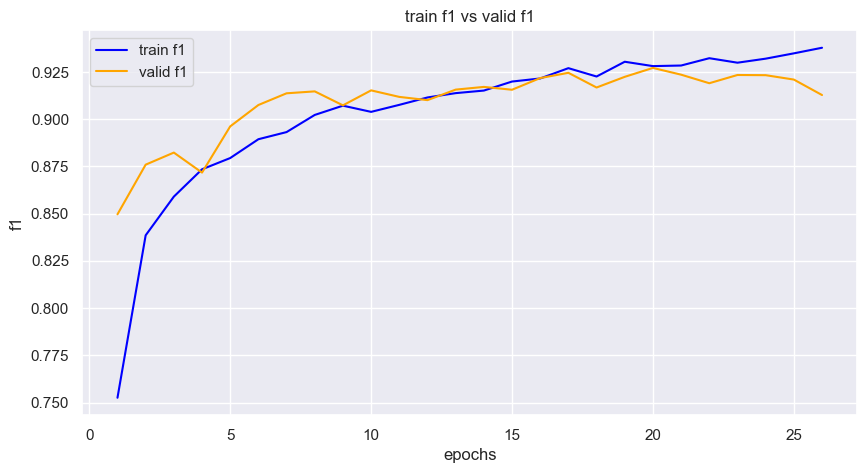

In [ ]:
plt.figure(figsize=(10, 5))
plt.title('train f1 vs valid f1')
plt.xlabel('epochs')
plt.ylabel('f1')
plt.plot(epochs, train_f1, color='blue', label='train f1')
plt.plot(epochs, valid_f1, color='orange', label='valid f1')
plt.legend()

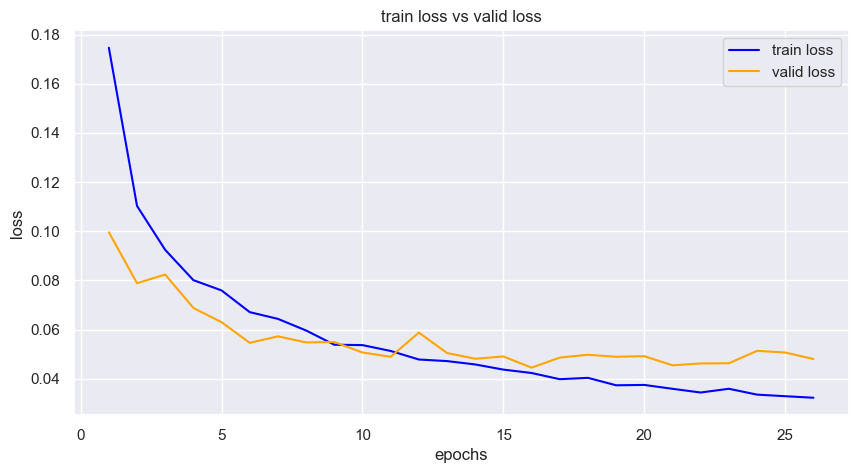

In [ ]:
plt.figure(figsize=(10, 5))
plt.title('train loss vs valid loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.plot(epochs, train_lossy, color='blue', label='train loss')
plt.plot(epochs, valid_lossy, color='orange', label='valid loss')
plt.legend()

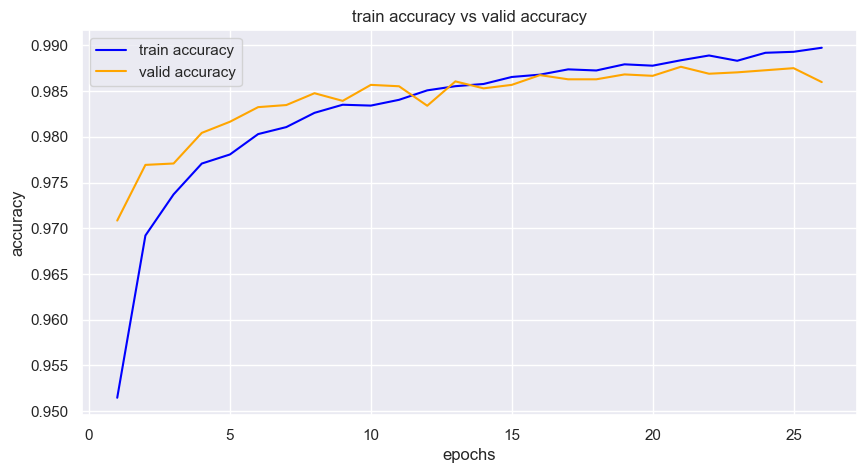

In [ ]:
plt.figure(figsize=(10,5))
plt.title('train accuracy vs valid accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.plot(epochs, train_accy, color='blue', label='train accuracy')
plt.plot(epochs, valid_accy, color='orange', label='valid accuracy')
plt.legend()

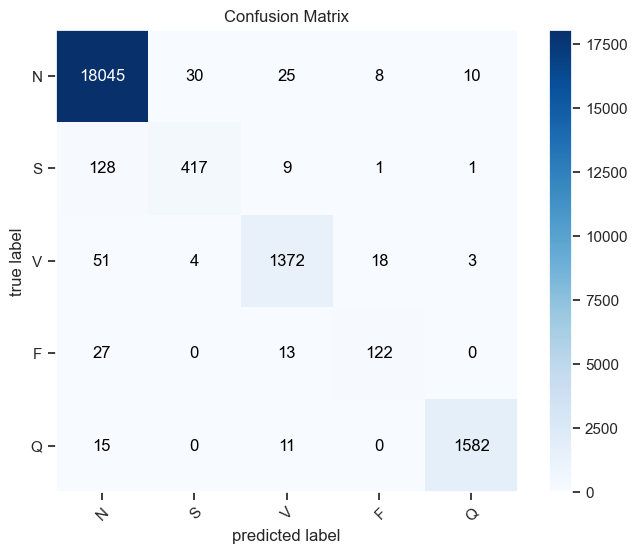

In [ ]:
from mlxtend.plotting import plot_confusion_matrix

class_names = [
    'N',
    'S',
    'V',
    'F',
    'Q'
]
# Confusion matrix for GRU
conf_matrix_gru = confusion_matrix(y_target_classes, y_pred_classes)

plot_confusion_matrix(conf_matrix_gru,
                      class_names=class_names,
                      figsize=(8,6),
                      colorbar=True)

plt.title('Confusion Matrix')
plt.show()

## 9. Results

Final performance:
- Accuracy: 98.67%
- F1-score: 92.38%
- Recall: 92.55%

The model shows strong performance, especially on minority classes.

## 10. Conclusion

This work demonstrates that combining GA-based optimization with class-aware augmentation yields a compact and effective ECG classification model.